In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

In [2]:
data = yf.download("AAPL", start="2024-01-01")

[*********************100%***********************]  1 of 1 completed


In [3]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.404007,186.170285,181.675085,184.895814,82488700
2024-01-03,182.030746,183.641118,181.220616,182.001109,58414500
2024-01-04,179.718918,180.884698,178.701325,179.956017,71983600
2024-01-05,178.997726,180.558698,177.999897,179.797983,62379700
2024-01-08,183.324966,183.364493,179.313871,179.896761,59144500


In [4]:
df=data.iloc[:,:-1]

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 667 entries, 2024-01-02 to 2026-08-28
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, AAPL)  666 non-null    float64
 1   (High, AAPL)   666 non-null    float64
 2   (Low, AAPL)    666 non-null    float64
 3   (Open, AAPL)   666 non-null    float64
dtypes: float64(4)
memory usage: 26.1 KB


In [6]:
df.dropna(inplace=True)

In [7]:
import matplotlib.pyplot as plt

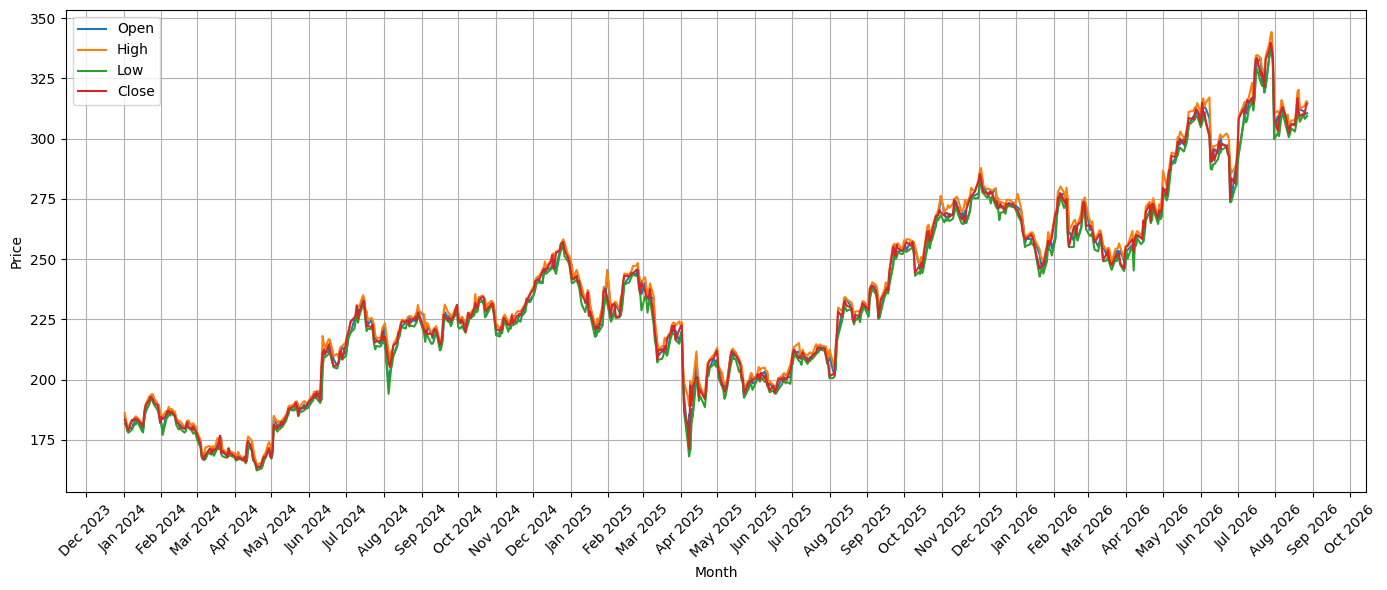

In [8]:

import matplotlib.dates as mdates
plt.figure(figsize=(14, 6))

for col in ['Open', 'High', 'Low', 'Close']:
    plt.plot(df.index, df[col], label=col)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xlabel('Month')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

<Figure size 1400x500 with 0 Axes>

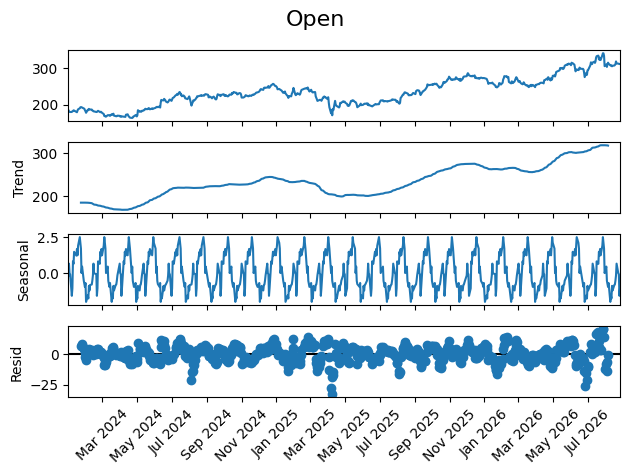

<Figure size 1400x500 with 0 Axes>

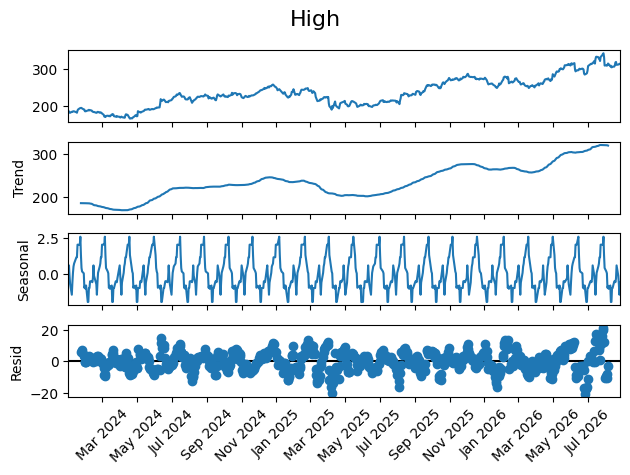

<Figure size 1400x500 with 0 Axes>

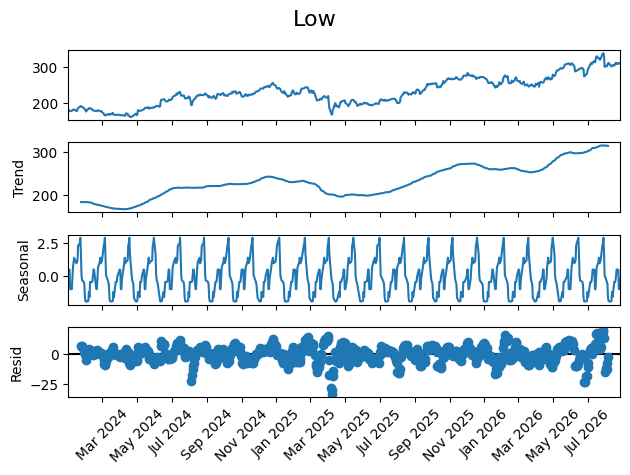

<Figure size 1400x500 with 0 Axes>

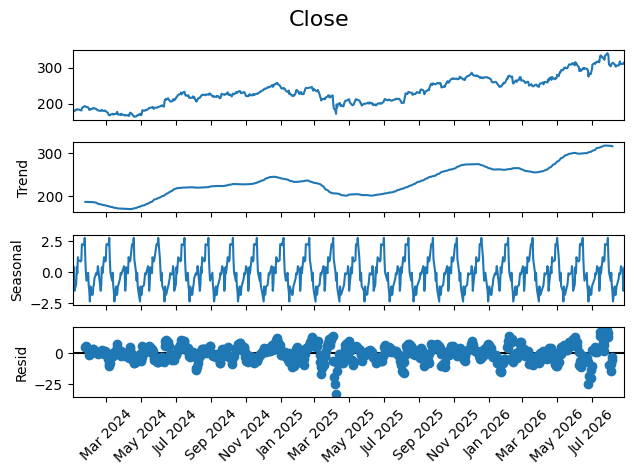

In [10]:
import matplotlib.dates as mdates
for col in ['Open', 'High', 'Low', 'Close']:
    result=seasonal_decompose(
        df[col],model='additive',period=30)
    fig=plt.figure(figsize=(14,5))
    result.plot()
    for ax in plt.gcf().axes:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x',labelrotation=45)
    plt.suptitle(col,fontsize=16)
    plt.tight_layout()
    plt.show()

In [11]:
from statsmodels.tsa.stattools import adfuller,kpss
def adf_test(series):
    adf_test=adfuller(series)
    print(f"adf stats:{round(adf_test[0],3)}")
    print(f"p-value stats:{round(adf_test[1],3)}")
   
        
def kpss_test(series):
    kpss_test=kpss(series,regression='ct')
    print("KPSS Statistic:", kpss_test[0])
    print("p-value:", kpss_test[1])
    

In [12]:
for col in ['Open', 'High', 'Low', 'Close']:
    adf_test(df[col])
    kpss_test(df[col])

adf stats:-0.987
p-value stats:0.758
KPSS Statistic: 0.32355765298981326
p-value: 0.01
adf stats:-0.748
p-value stats:0.834
KPSS Statistic: 0.3249397141294903
p-value: 0.01
adf stats:-0.906
p-value stats:0.786
KPSS Statistic: 0.3231698932614727
p-value: 0.01
adf stats:-0.699
p-value stats:0.847
KPSS Statistic: 0.32400511110084745
p-value: 0.01


C:\Users\Mcc\AppData\Local\Temp\ipykernel_4216\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_4216\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_4216\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_4216\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-va

In [13]:
df_diff=df.diff().dropna()

In [14]:
df_diff

Price,Close,High,Low,Open
Ticker,AAPL,AAPL,AAPL,AAPL
Date,,,,
2024-01-03,-1.373260,-2.529166,-0.454469,-2.894705
2024-01-04,-2.311829,-2.756421,-2.519291,-2.045092
2024-01-05,-0.721191,-0.326000,-0.701428,-0.158035
2024-01-08,4.327240,2.805796,1.313974,0.098778
2024-01-09,-0.414948,-0.444600,1.215173,1.807952
...,...,...,...,...
2026-08-21,-1.949982,-7.899994,-3.639984,-5.410004
2026-08-24,0.989990,0.979980,2.959991,-0.579987


In [15]:
df_diff.isnull().sum()

Price  Ticker
Close  AAPL      0
High   AAPL      0
Low    AAPL      0
Open   AAPL      0
dtype: int64

In [16]:
from statsmodels.tsa.stattools import adfuller,kpss
def adf_test(series):
    adf_test=adfuller(series)
    print(f"adf stats:{round(adf_test[0],3)}")
    print(f"p-value stats:{round(adf_test[1],3)}")
   
        
def kpss_test(series):
    kpss_test=kpss(series,regression='ct')
    print("KPSS Statistic:", kpss_test[0])
    print("p-value:", kpss_test[1])
    

In [17]:
for col in ['Open', 'High', 'Low', 'Close']:
    adf_test(df_diff[col])
    kpss_test(df_diff[col])

adf stats:-15.733
p-value stats:0.0
KPSS Statistic: 0.0371278172553607
p-value: 0.1
adf stats:-14.001
p-value stats:0.0
KPSS Statistic: 0.04038094860653835
p-value: 0.1
adf stats:-13.985
p-value stats:0.0
KPSS Statistic: 0.03612584145552125
p-value: 0.1


C:\Users\Mcc\AppData\Local\Temp\ipykernel_4216\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_4216\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_4216\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test=kpss(series,regression='ct')


adf stats:-13.064
p-value stats:0.0
KPSS Statistic: 0.03664656259875018
p-value: 0.1


C:\Users\Mcc\AppData\Local\Temp\ipykernel_4216\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test=kpss(series,regression='ct')


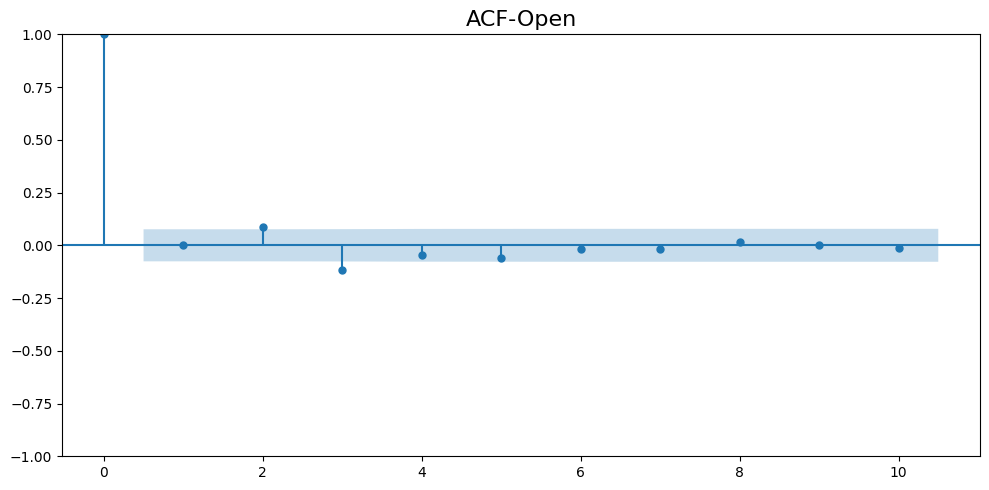

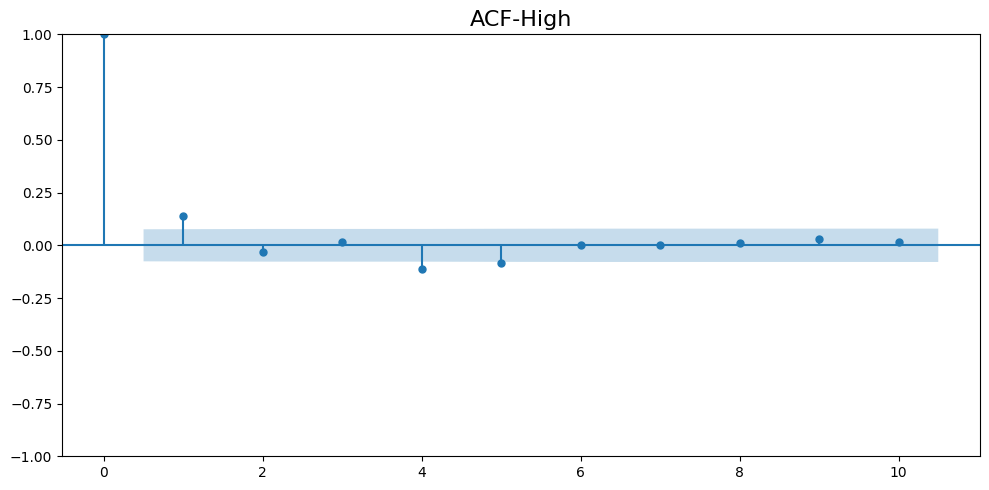

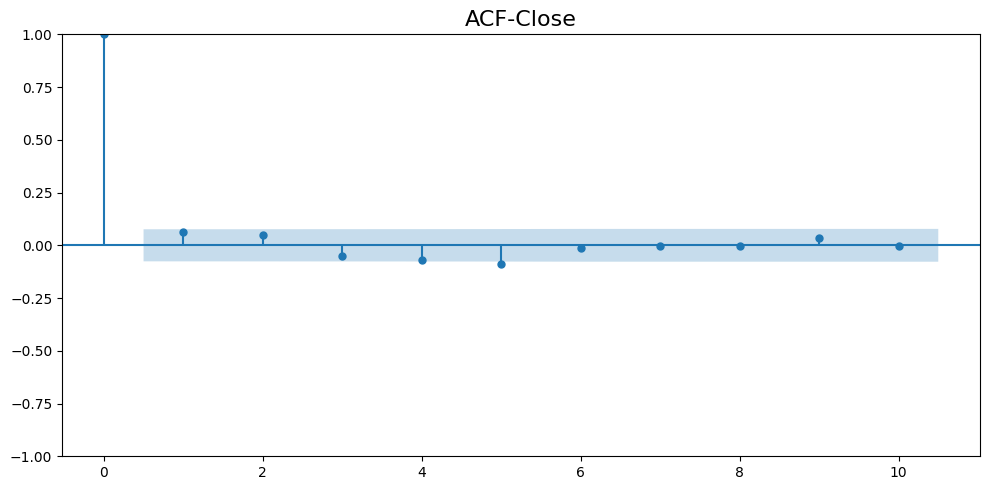

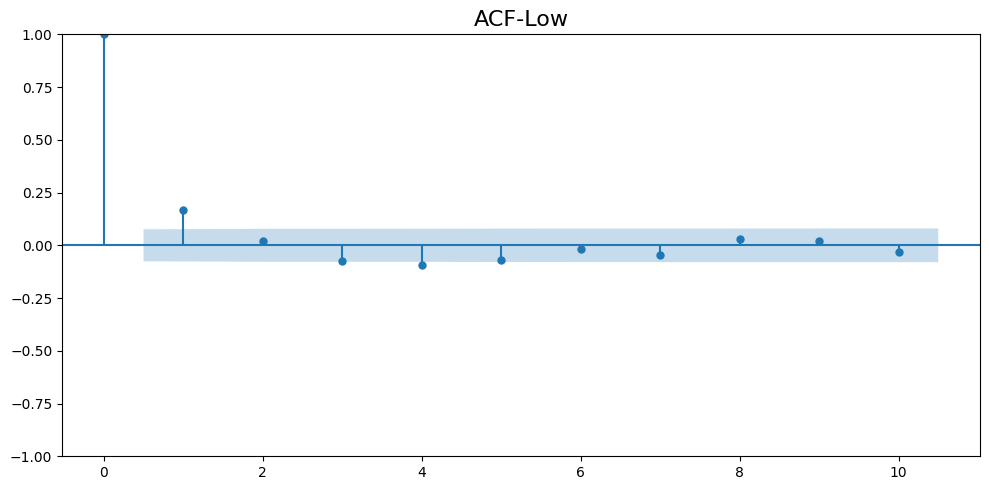

In [18]:
from statsmodels.graphics.tsaplots import plot_acf
for col in ['Open','High','Close','Low']:
    fig,ax=plt.subplots(figsize=(10,5))
    plot_acf(df_diff[col].dropna(),lags=10,ax=ax)
    ax.set_title(f'ACF-{col}',fontsize=16)
    plt.tight_layout()
    plt.show()
    

In [19]:
train=df_diff[:600]
test=df_diff[600:]

In [20]:
train.isna().sum()

Price  Ticker
Close  AAPL      0
High   AAPL      0
Low    AAPL      0
Open   AAPL      0
dtype: int64

In [21]:
test.isna().sum()

Price  Ticker
Close  AAPL      0
High   AAPL      0
Low    AAPL      0
Open   AAPL      0
dtype: int64

In [22]:
# trend='n'   # no trend
# trend='c'   # constant
# trend='t'   # linear trend
# trend='ct'  # constant + linear trend

In [23]:
from statsmodels.tsa.statespace.varmax import VARMAX

In [70]:
model = VARMAX(
    train,
    order=(5, 5),
    trend='c'
)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\statespace\varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [71]:
# disp=False → don't show optimization progress
# maxiter=500 → allow up to 500 optimization iterations
# results.summary() → show the final model results

In [72]:

results = model.fit(
    disp=True,
    maxiter=500
)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [73]:
print(results.summary())

                                            Statespace Model Results                                            
Dep. Variable:     ['Close_AAPL', 'High_AAPL', 'Low_AAPL', 'Open_AAPL']   No. Observations:                  600
Model:                                                       VARMA(5,5)   Log Likelihood               -4841.278
                                                            + intercept   AIC                          10030.556
Date:                                                  Sun, 30 Aug 2026   BIC                          10795.622
Time:                                                          10:19:45   HQIC                         10328.381
Sample:                                                               0                                         
                                                                  - 600                                         
Covariance Type:                                                    opg                         

In [74]:
print(results.mle_retvals)

{'fopt': np.float64(8.068796901843552), 'gopt': array([ 4.59050624e-01, -3.07817879e-01, -3.99281513e-01,  2.22956000e-01,
       -2.48114187e-03, -6.54173391e-03,  1.65755292e-02,  3.02320291e-02,
       -2.24678436e-02, -1.79409554e-02, -1.76946360e-02,  6.14435116e-03,
       -2.41121182e-02,  1.76741784e-02, -1.39688954e-02,  8.68584138e-04,
       -4.47654489e-02,  3.96169888e-03,  2.52361918e-03, -1.02246441e-02,
       -3.38759728e-02,  2.78508416e-03, -2.40266385e-03,  1.77374684e-03,
       -7.43373789e-02, -1.64859751e-02, -1.64999774e-02, -2.60500379e-02,
       -5.41288768e-02,  4.98592829e-03,  7.49931193e-03, -6.19418206e-03,
       -1.63216290e-02, -2.09984776e-03,  1.84405273e-02, -3.54596672e-03,
       -4.86296964e-02, -5.99639858e-03,  2.03192462e-02, -1.56851669e-03,
       -4.25204531e-02, -2.85216487e-02,  3.26541453e-02,  1.19526558e-02,
       -5.08464014e-02, -9.42920693e-03,  4.99762223e-03, -2.02698397e-02,
       -4.84828567e-02,  5.61983509e-03,  1.05061810

In [75]:
# converged → whether the optimizer successfully converged.
# warnflag → optimizer warning/status code. 0 commonly means successful convergence.
# fopt → final value of the objective function.
# fcalls → number of objective-function evaluations.
# gcalls → number of gradient evaluations.
# gopt → gradient at the final solution.

In [76]:
test.shape

(65, 4)

In [77]:
forecast_diff = results.forecast(steps=len(df[600:]))

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [78]:
forecast_diff

,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL
600,-0.141543,-0.825777,-2.376747,-1.300449
601,0.096537,0.040709,-0.059059,-0.338408
602,0.219985,-0.084213,0.202290,0.091476
603,0.388779,0.498535,0.407304,0.365541
604,0.395010,0.456682,0.647495,0.715773
...,...,...,...,...
661,0.216638,0.218750,0.212117,0.214463
662,0.216638,0.218750,0.212117,0.214463
663,0.216638,0.218750,0.212117,0.214463
664,0.216638,0.218750,0.212117,0.214463


In [79]:
forecast_diff.index=df[600:].index

In [80]:
forecast_diff

,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL
Date,,,,
2026-05-26,-0.141543,-0.825777,-2.376747,-1.300449
2026-05-27,0.096537,0.040709,-0.059059,-0.338408
2026-05-28,0.219985,-0.084213,0.202290,0.091476
2026-05-29,0.388779,0.498535,0.407304,0.365541
2026-06-01,0.395010,0.456682,0.647495,0.715773
...,...,...,...,...
2026-08-21,0.216638,0.218750,0.212117,0.214463
2026-08-24,0.216638,0.218750,0.212117,0.214463
2026-08-25,0.216638,0.218750,0.212117,0.214463


In [81]:
last_value=df[:600].iloc[-1]


In [82]:
forecast = pd.DataFrame(
    forecast_diff.cumsum().values + last_value.values,
    index=forecast_diff.index,
    columns=forecast_diff.columns
)

In [83]:
forecast

,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL
Date,,,,
2026-05-26,308.412351,310.305881,303.199704,304.555759
2026-05-27,308.508888,310.346590,303.140645,304.217351
2026-05-28,308.728873,310.262376,303.342936,304.308827
2026-05-29,309.117652,310.760912,303.750240,304.674368
2026-06-01,309.512662,311.217593,304.397734,305.390141
...,...,...,...,...
2026-08-21,321.938101,323.738994,316.488225,317.640224
2026-08-24,322.154739,323.957744,316.700342,317.854686
2026-08-25,322.371377,324.176494,316.912459,318.069149


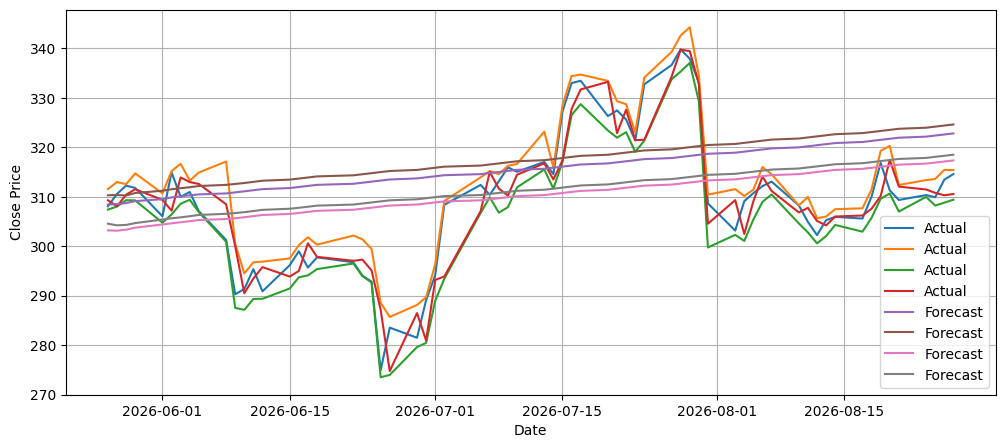

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(df[600:], label='Actual')
plt.plot(forecast, label='Forecast')

plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()

In [85]:
df[600:].shape,forecast.shape

((66, 4), (66, 4))

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    df[600:],
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        df[600:],
        forecast
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 11.124718659870872
RMSE: 13.450143849823032


In [95]:
model = VARMAX(
    df_diff,
    order=(2, 2)
)

results = model.fit()

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\statespace\varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [96]:
steps = 10

# Forecast next 10 differences
future_diff = results.forecast(steps=steps)
last_value = df.iloc[-1]
future = future_diff.cumsum().add(
    last_value.to_numpy(),
    axis=1
)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [102]:
future.shape

(10, 4)

Timestamp('2026-08-27 00:00:00')

In [106]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=steps
)

future.index = future_dates

print(future)

            Close_AAPL   High_AAPL    Low_AAPL   Open_AAPL
2026-08-28  314.859709  317.314696  311.328818  313.860723
2026-08-29  315.610552  318.347356  312.175631  314.771466
2026-08-30  315.296332  318.322066  312.094231  315.149970
2026-08-31  315.338984  318.312358  312.025420  314.945997
2026-09-01  315.464967  318.425906  312.075158  315.042169
2026-09-02  315.684047  318.600530  312.255615  315.149592
2026-09-03  315.891263  318.825557  312.451301  315.370945
2026-09-04  316.095115  319.035600  312.652080  315.566616
2026-09-05  316.283547  319.242014  312.832832  315.765097
2026-09-06  316.472195  319.440679  313.012800  315.949974


In [107]:
future

,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL
2026-08-28,314.859709,317.314696,311.328818,313.860723
2026-08-29,315.610552,318.347356,312.175631,314.771466
2026-08-30,315.296332,318.322066,312.094231,315.149970
2026-08-31,315.338984,318.312358,312.025420,314.945997
2026-09-01,315.464967,318.425906,312.075158,315.042169
2026-09-02,315.684047,318.600530,312.255615,315.149592
2026-09-03,315.891263,318.825557,312.451301,315.370945
2026-09-04,316.095115,319.035600,312.652080,315.566616
2026-09-05,316.283547,319.242014,312.832832,315.765097
2026-09-06,316.472195,319.440679,313.012800,315.949974
